# Phase 1 — What is the train doing? (Operational states)

This notebook finds the train's basic **operational states** — *standing,
accelerating, cruising, braking* — directly from the data, and checks they make
physical sense.

The important design choice: we define these states from the train's **motion only**
(speed and acceleration), and deliberately keep the air-brake/pressure sensors out of
that definition. That keeps those sensors as *independent evidence* for Phase 2 — see
**leakage** in the glossary for why this matters.

> **How to read this notebook.** Each step has three short notes:
> **What we did** (the action), **What it means** (the plain-English result), and
> **How confident** (how much to trust it). Technical terms are explained at the very
> bottom, in *"Techniques explained"* — every method used here is in that glossary with
> an everyday analogy. Nothing assumes a data-science background.

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES = ROOT / "results" / "tables"
P1 = ROOT / "results" / "plots" / "phase1"
P2 = ROOT / "results" / "plots" / "phase2"
LOGS = ROOT / "logs"
pd.set_option("display.max_columns", 40)
print("Project root:", ROOT)

Project root: C:\Users\MSC\Programming\Interdisciplinary Project


## 1. From raw sensors to 10-second windows

**What we did:** the train logs ~100 sensors once per second for a year. We summarise
each non-overlapping **10-second window** (its average speed, how much it sped up or
slowed down, etc.). The 10-second window is our unit of analysis.

**What it means:** instead of 30 million raw rows we work with ~1.5 million tidy windows,
each describing a short slice of driving.

**How confident:** this is a standard, lossless-enough summarisation; window length
(10 s) was fixed earlier in the project.

## 2. How many states are there? (we measure, not guess)

**What we did:** we grouped the windows by motion using two independent methods
(**k-means** and **hierarchical clustering**) and scored candidate group-counts with
**silhouette**, **Davies–Bouldin**, and **stability (bootstrap ARI)**. See glossary.

,k,silhouette,davies_bouldin,kmeans_vs_hier_ari
0,2,0.476,0.999,NaN
1,3,0.535,1.196,0.811
2,4,0.567,1.091,0.766
3,5,0.587,0.990,NaN
4,6,0.605,0.945,NaN


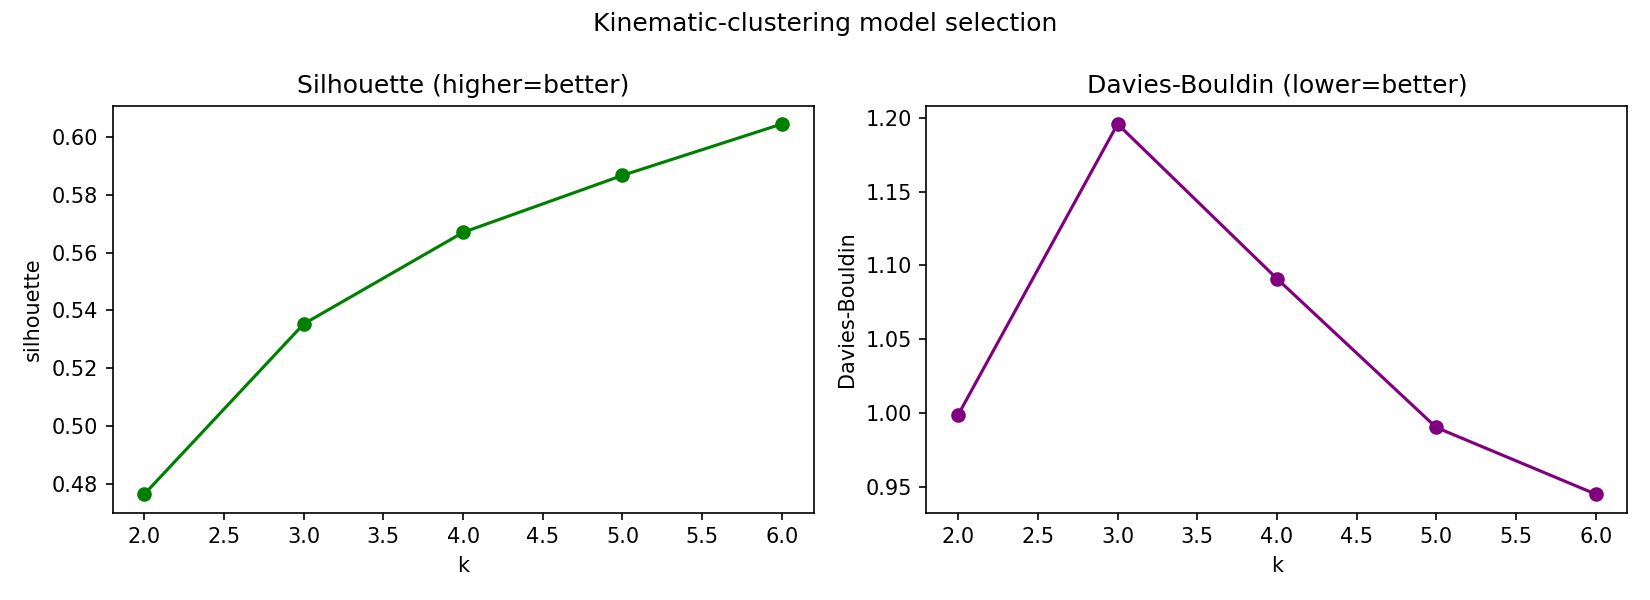

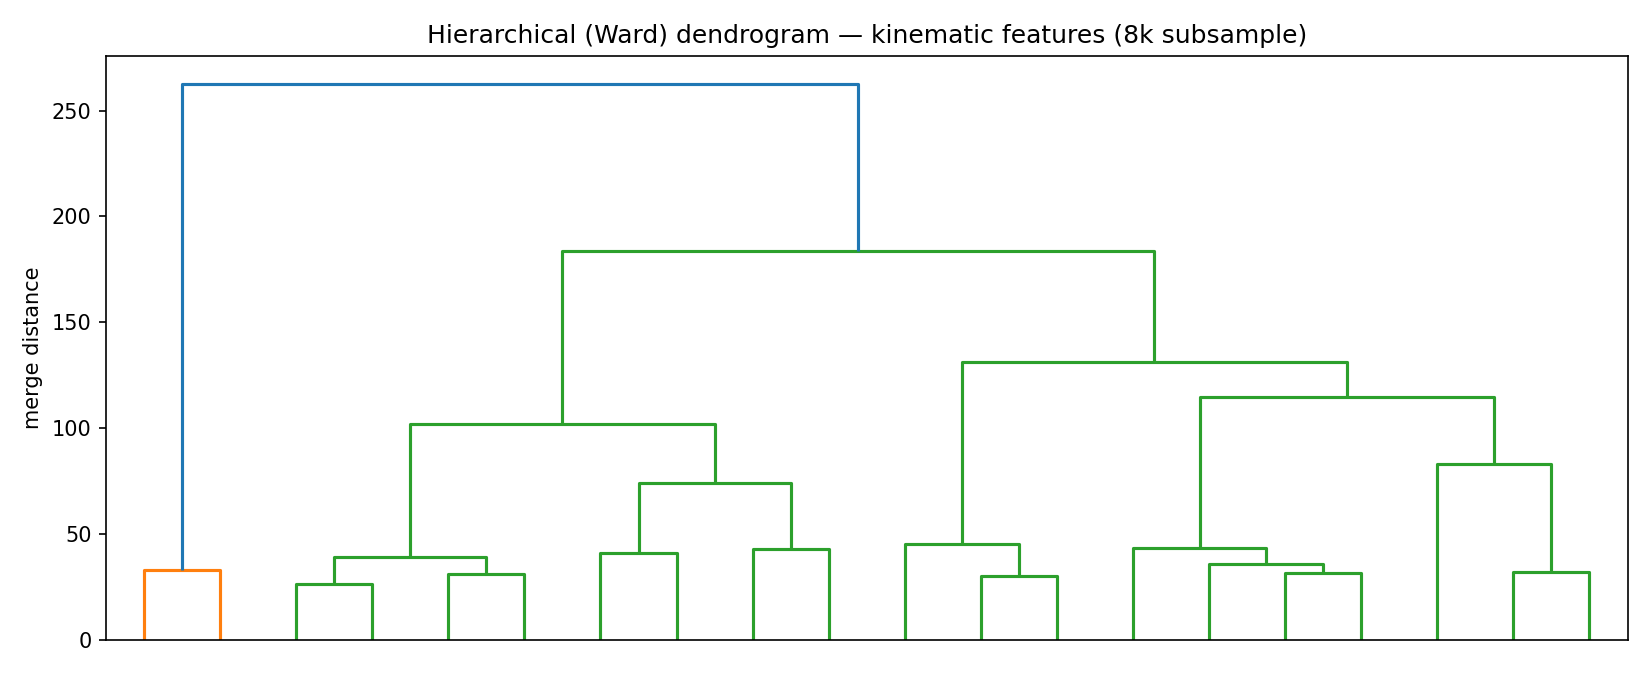

In [2]:
display(pd.read_csv(TABLES / "phase1_kselection.csv").round(3))
display(Image(filename=str(P1 / "kinematic_kselection.png")))
display(Image(filename=str(P1 / "dendrogram.png")))

**What it means:** four groups (**k = 4**) give the cleanest, most
physically meaningful split, and the two methods agree (high ARI).

**How confident:** good — the four groups are stable under resampling. (Three groups also
works statistically but is physically muddier: it has no steady "cruising" state.)

## 3. The four operational states

**What we did:** we named each group from its physical profile (median speed and
acceleration).

,n,pct,median_velocity,median_accel
state,,,,
standing,717211,48.12,0.0000,0.0000
accelerating,213807,14.34,0.3046,0.0410
cruising,257471,17.27,0.8421,0.0019
braking,302008,20.26,0.3432,-0.0327


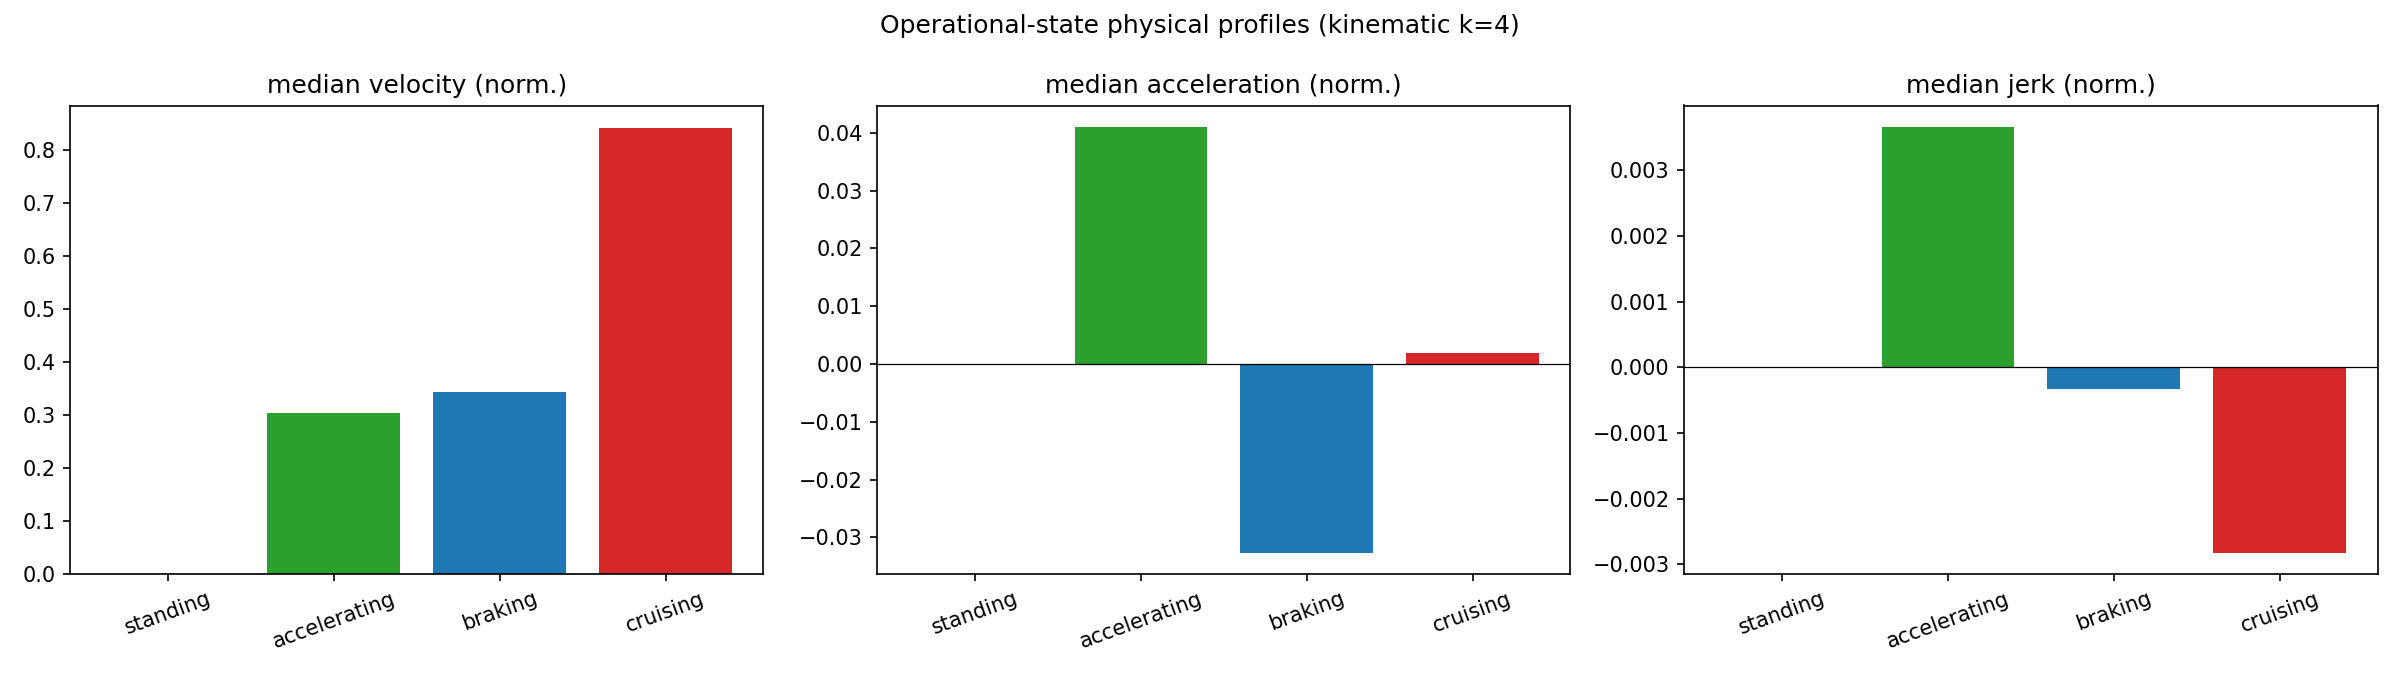

In [3]:
display(pd.read_csv(TABLES / "phase1_state_summary.csv", index_col=0).round(4))
display(Image(filename=str(P1 / "state_profiles.png")))

**What it means:**
- **standing** — not moving (~48% of the time).
- **accelerating** — speed rising (positive acceleration, ~14%).
- **cruising** — high steady speed (~17%).
- **braking** — speed falling (negative acceleration, ~20%).

Crucially, **braking now means *actually slowing down*** (negative acceleration), not a
parked train with the brake held.

**How confident:** high — the profiles are clean and physically sensible.

## 4. The "held brake" discovery (why we re-did Phase 1)

**What we did:** an earlier version included the brake-pressure sensors when defining the
states. That made a *stationary train holding its brake* (at a station) look like
"braking", because the brake pressure is high even though the train isn't moving. Defining
states from motion only fixes this. We also keep the useful information as a **sub-label**
of standing: `standing_braked` vs `standing_idle`.

In [4]:
print("Old-state vs new-state cross-tab (how windows were relabelled):")
display(pd.read_csv(TABLES / "phase1_new_vs_old_states.csv", index_col=0))

Old-state vs new-state cross-tab (how windows were relabelled):


,accelerating,braking,cruising,standing
old_state,,,,
braking,80226,104908,519,46723
cruising,133579,196610,256950,46422
standing,2,490,2,624066


**What it means:** the old "braking" group was contaminated — a large
chunk of it was really *standing* (brake held) or even *accelerating*. The new motion-based
states separate these correctly.

**How confident:** high, and it materially improves everything downstream — Phase 2's
braking analysis is now about genuine decelerations.

## 5. How the train moves between states

**What we did:** we measured how often each state follows another (transition
probabilities) and how long the train typically stays in each (dwell times).

,mean,std,count
state,,,
standing,54.2,641.0,132245
accelerating,17.1,5.0,124901
cruising,20.8,10.6,123545
braking,23.8,7.2,127055


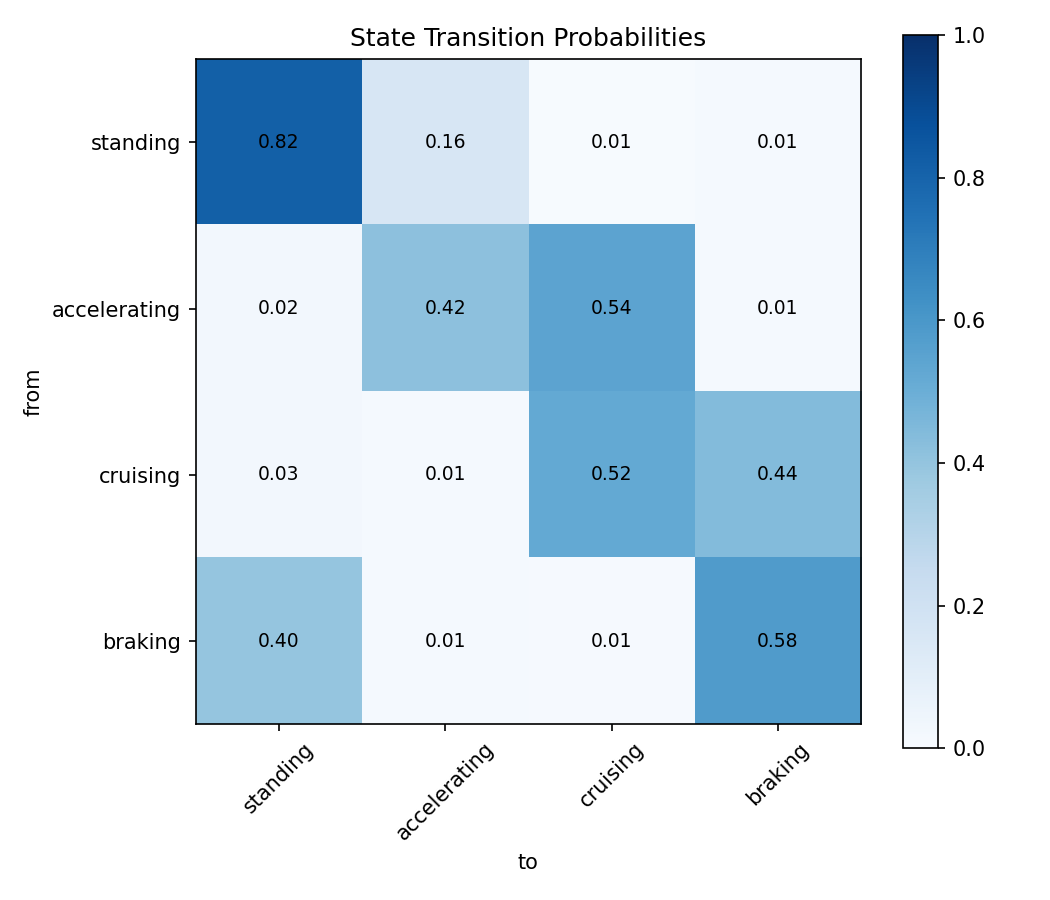

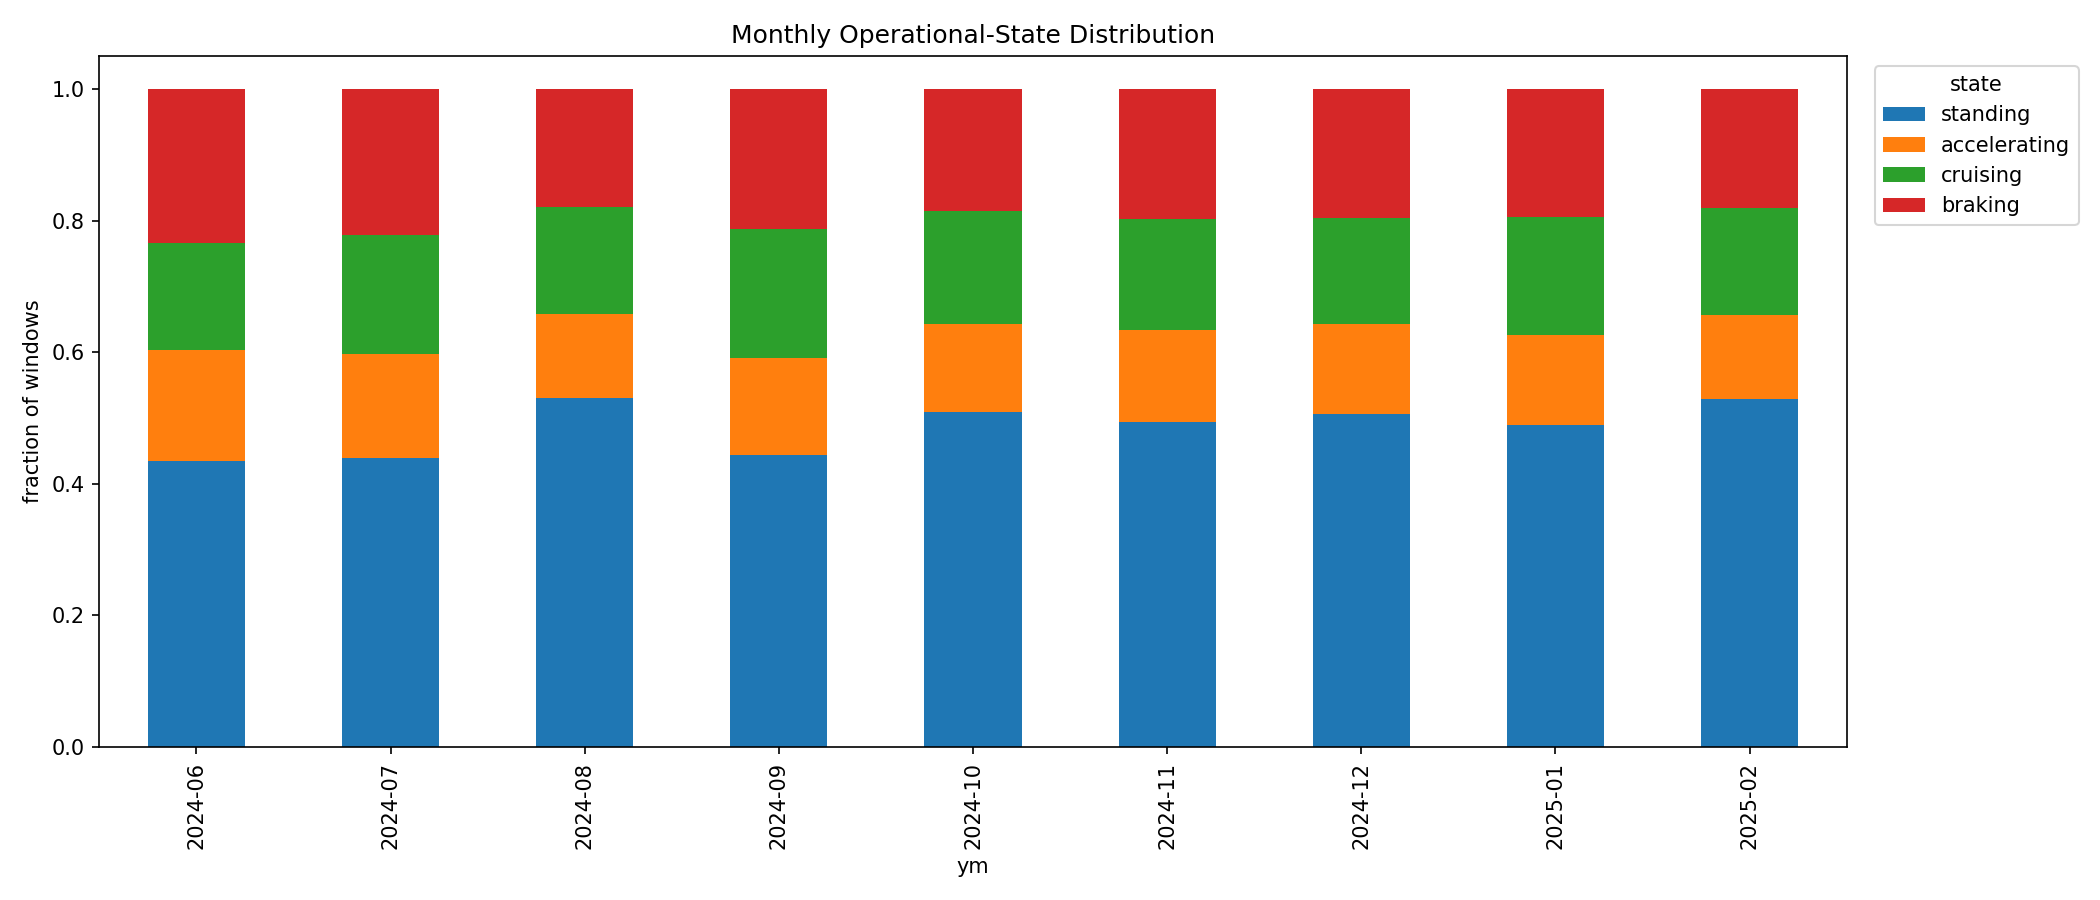

In [5]:
display(pd.read_csv(TABLES / "dwell_times.csv", index_col=0).round(1))
display(Image(filename=str(P1 / "transition_diagram.png")))
display(Image(filename=str(P1 / "state_distribution_by_month.png")))

**What it means:** the sequence matches normal metro operation
(stop → accelerate → cruise → brake → stop), and the mix of states is stable month to
month.

**How confident:** high — this is descriptive and consistent across the year.

## Techniques explained (plain language)

Each method we used, with an everyday analogy.

**Normalization / standardization** — Sensors come in different units and ranges. We
rescale each one so they're comparable (think: converting everyone's height and weight
to "how many standard deviations above/below average" so neither dominates just because
its numbers are bigger).

**Clustering** — Letting the data sort itself into natural groups, without telling it
the answer in advance (like sorting a pile of mixed coins into piles by size without
being told the denominations).

**k-means** — A clustering method: you pick how many groups *k* you want; it places *k*
"centres" and assigns each point to its nearest centre, then nudges the centres until
they settle. Fast and simple.

**Hierarchical clustering + dendrogram** — Builds a family tree of the data by repeatedly
merging the two closest groups. The tree (dendrogram) shows at what "distance" groups
merge, which hints at how many real groups there are. We run it on a sample because it's
memory-heavy on millions of rows.

**Choosing the number of groups (k):** we don't guess — we measure.
- **Silhouette** — how tightly packed and well-separated the groups are (higher = cleaner;
  ~1 is perfect, ~0 means overlapping).
- **Davies–Bouldin** — similar idea, lower = better.
- **BIC / AIC** — score a statistical model that rewards fitting the data but penalises
  needless complexity. A genuine "best k" shows up as a low point; if the score just keeps
  improving with more groups, there is no natural number of groups (a *continuum*).
- **Bootstrap + Adjusted Rand Index (ARI)** — re-draw the data many times, re-cluster, and
  check the groupings still agree (ARI ≈ 1 = stable, ≈ 0 = random). Stability is the
  decisive test: pretty groups that don't survive resampling aren't real.

**PCA (Principal Component Analysis)** — Squeezes many correlated sensors into a few
summary axes that capture most of the variation (like summarising a detailed survey by
its two or three main themes). Useful for plotting and for an *anomaly score*: if a
reading can't be rebuilt from those summary axes, it's unusual.

**Train / held-out split** — We fit models on one part of the data and score them on a
*different, unseen* part. Scoring on data the model already saw would be like grading an
exam with the answer key taped to it — meaningless.

**Decision tree / LDA / QDA** — Three transparent ways to draw the boundary between
classes: a decision tree asks a sequence of yes/no questions ("is pressure > x?"); LDA
draws a straight dividing line; QDA allows a curved one. We report all three so the result
doesn't depend on one method's quirks.

**Scoring a classifier:**
- **Accuracy** — fraction correct. Misleading when one class is rare.
- **Balanced accuracy** — accuracy averaged per class, so a rare class still counts.
- **Precision** — of the cases flagged positive, how many really were.
- **Recall** — of the real positives, how many we caught.
- **F1** — the balance of precision and recall (one number).
- **ROC-AUC** — probability the model ranks a real positive above a real negative; 0.5 =
  coin-flip, 1.0 = perfect.
- **Confusion matrix** — the table of right/wrong calls per class.

**Regression & R²** — Predicting a number (not a class). **R²** is the fraction of the
real variation the model explains: 0 = no better than always guessing the average, 1 =
perfect. **MAE** is the average size of the error. We always compare against a
**baseline** (guess-the-average) so the number means something.

**Comparing two groups of measurements:**
- **Mann–Whitney U / Kolmogorov–Smirnov** — tests for whether two groups differ.
- **p-value** — the chance of seeing a difference this big if there were truly none. With
  huge samples, *even trivial differences get tiny p-values*, so a small p alone is not
  "important".
- **Cliff's delta** — the *effect size*: how large the difference actually is (0 = none,
  ±1 = total separation). This is what we read, not the p-value alone.
- **Bonferroni correction** — when you run many tests, you tighten the bar to avoid being
  fooled by chance.

**CUSUM** — A cumulative drift alarm: it adds up small deviations from normal and raises a
flag once they pile up, good at catching slow trends. **Lead time** = how far ahead of a
failure it fired; **false-alarm rate** = how often it cries wolf.

**SHAP** *(used in Phase 3)* — Explains a prediction by how much each sensor pushed it up
or down, like an itemised receipt for the model's decision.

**Leakage / circularity (the key idea behind this whole study)** — A predictor must never
have helped define the thing it's predicting. If you label "hard braking" using
deceleration and then "predict" that label using deceleration, you've just memorised your
own definition — you'll score ~100 % and learn nothing. We avoid this by defining
operational states from **motion only** and predicting them from the **air-system sensors
only**, which never touched the definition.